# **Setup**

In [5]:
%pip install pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Part 1. Load and Prepare the Dataset**

In [4]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


### Binarization of a Target Column

In [5]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
})

df["Heart Disease"].value_counts()

Heart Disease
0    150
1    120
Name: count, dtype: int64

### General Data

In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


### Missing cells and Outliers

In [7]:
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if missing_summary.empty:
    print("There are no missing cells on the dataset.")
else:
    print("Missing cells by column:")
    print(missing_summary)

There are no missing cells on the dataset.


In [9]:
numerical_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"]

outliers = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_values = df[(df[col] < lower) | (df[col] > upper)][col].values
    
    if len(outlier_values) > 0:
        outliers[col] = outlier_values

if outliers:
    print("Detected outliers by feature:")
    for feature, values in outliers.items():
        print(f"{feature}: {values}")
else:
    print("No extreme outliers detected.")


Detected outliers by feature:
BP: [174 178 180 200 192 178 180 180 172]
Cholesterol: [564 407 417 409 394]
Max HR: [71]
ST depression: [4.2 5.6 4.2 6.2]
Number of vessels fluro: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [10]:
df_capped = df.copy()

numerical_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"]

for col in numerical_features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

### Plot Class Distribution

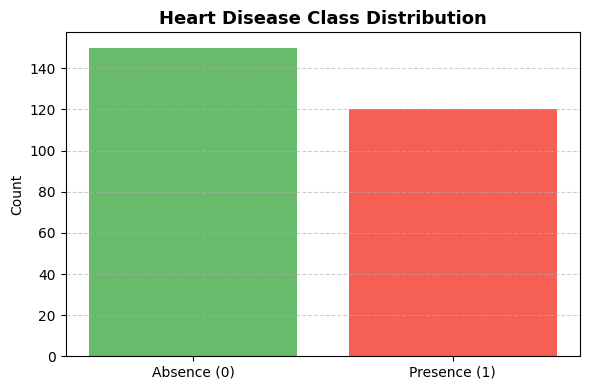

In [15]:
counts = df["Heart Disease"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Absence (0)", "Presence (1)"], counts,
        color=["#4CAF50", "#F44336"],
        alpha=0.85
)
plt.ylabel("Count")
plt.title("Heart Disease Class Distribution", fontsize=13, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

###  70/30 train/test split

In [16]:
features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression", "Number of vessels fluro"]
X = df_capped[features].values
y = df_capped["Heart Disease"].values

In [17]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

split_0 = int(0.7 * len(idx_0))
split_1 = int(0.7 * len(idx_1))

train_idx = np.concatenate([idx_0[:split_0], idx_1[:split_1]])
test_idx  = np.concatenate([idx_0[split_0:], idx_1[split_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training set class distribution:", np.bincount(y_train))
print("Testing set class distribution:", np.bincount(y_test))

Training set class distribution: [105  84]
Testing set class distribution: [45 36]


In [18]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm  = (X_test - mu) / sigma

### Heart Disease Dataset: Overview and Preprocessing

#### Dataset Overview
The dataset was downloaded from Kaggle and contains 270 patient records with clinical features related to heart health.  
- Target variable: Heart Disease (1 = presence, 0 = absence)  
- Class distribution: ~66% with disease, ~45% without disease  

#### Exploratory Data Analysis (EDA)
- Features include Age, BP, Cholesterol, Max HR, ST depression, and Number of vessels.  
- No missing values were found.  
- Outliers were detected in Cholesterol, BP, and ST depression but were clinically plausible.

#### Preprocessing
- Outliers were capped at 1.5×IQR boundaries to limit extreme values.  
- Numerical features were normalized using z-score scaling.  
- Data was split into 70% training and 30% testing using a stratified approach to preserve class proportions.  

#### Summary
The dataset is clean, normalized, and ready for binary classification. Selected features cover key indicators of heart health, and preprocessing ensures fair model training.


# **Part 2. Implement Basic Logistic Regression**

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = len(y)
    z = X.dot(w) + b
    y_hat = sigmoid(z)
    cost = -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1 - y)*np.log(1 - y_hat + 1e-8))
    return cost

def compute_gradients(X, y, w, b):
    m = len(y)
    z = X.dot(w) + b
    y_hat = sigmoid(z)
    dw = (1/m) * X.T.dot(y_hat - y)
    db = (1/m) * np.sum(y_hat - y)
    return dw, db

def gradient_descent(X, y, w, b, alpha=0.01, num_iters=1000):
    costs = []
    for i in range(num_iters):
        dw, db = compute_gradients(X, y, w, b)
        w -= alpha * dw
        b -= alpha * db
        if i % 10 == 0:
            cost = compute_cost(X, y, w, b)
            costs.append(cost)
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.4f}")
    return w, b, costs

Iteration 0: Cost = 0.6916
Iteration 100: Cost = 0.5918
Iteration 200: Cost = 0.5482
Iteration 300: Cost = 0.5257
Iteration 400: Cost = 0.5125
Iteration 500: Cost = 0.5041
Iteration 600: Cost = 0.4984
Iteration 700: Cost = 0.4943
Iteration 800: Cost = 0.4912
Iteration 900: Cost = 0.4889


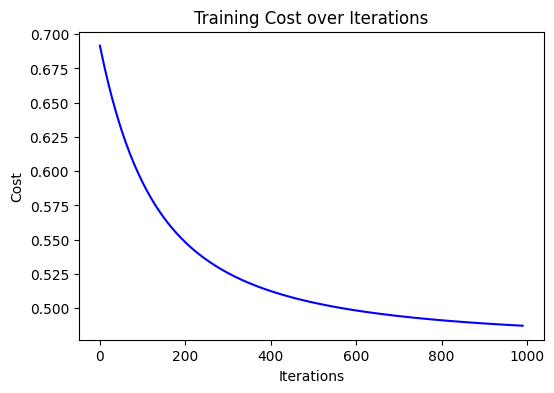

In [24]:
n_features = X_train_norm.shape[1]
w = np.zeros(n_features)
b = 0.0

w, b, costs = gradient_descent(X_train_norm, y_train, w, b, alpha=0.01, num_iters=1000)

plt.figure(figsize=(6,4))
plt.plot(range(0, len(costs)*10, 10), costs, color='blue')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost over Iterations")
plt.show()

In [21]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X.dot(w) + b)
    return (probs >= threshold).astype(int)

def evaluate(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    
    return accuracy, precision, recall, f1

y_train_pred = predict(X_train_norm, w, b)
y_test_pred  = predict(X_test_norm, w, b)

train_metrics = evaluate(y_train, y_train_pred)
test_metrics  = evaluate(y_test, y_test_pred)

print("Training Metrics: Accuracy={:.3f}, Precision={:.3f}, Recall={:.3f}, F1={:.3f}".format(*train_metrics))
print("Testing Metrics:  Accuracy={:.3f}, Precision={:.3f}, Recall={:.3f}, F1={:.3f}".format(*test_metrics))


Training Metrics: Accuracy=0.767, Precision=0.778, Recall=0.667, F1=0.718
Testing Metrics:  Accuracy=0.852, Precision=0.853, Recall=0.806, F1=0.829
